# pipeline test

In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.ops import polygonize
import matplotlib.pyplot as plt

In [2]:
from IPython.display import Image


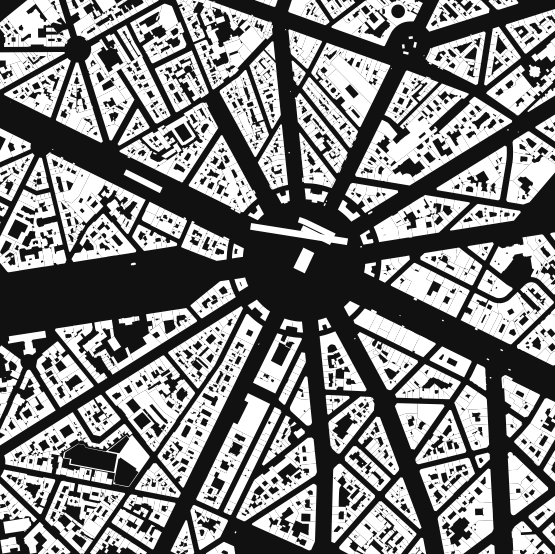

In [3]:
img_folder = "images"
extension = "png"
point = (48.873446, 2.294255)
dist = 612
tags = {"building": True}
gdf = ox.features.features_from_point(point, tags, dist=dist)
gdf_proj = ox.projection.project_gdf(gdf)
bbox = ox.utils_geo.bbox_from_point(point=point, dist=dist, project_utm=True)
fp = f"./{img_folder}/paris_bldgs.{extension}"
fig, ax = ox.plot.plot_footprints(
    gdf_proj,
    bbox=bbox,
    color="w",
    filepath=fp,
    dpi=90,
    save=True,
    show=False,
    close=True,
)

size = 240
Image(fp, height=size, width=size)

In [5]:
place = "Paris, France"

G = ox.graph_from_place(
    place,
    network_type="all",
    simplify=True
)

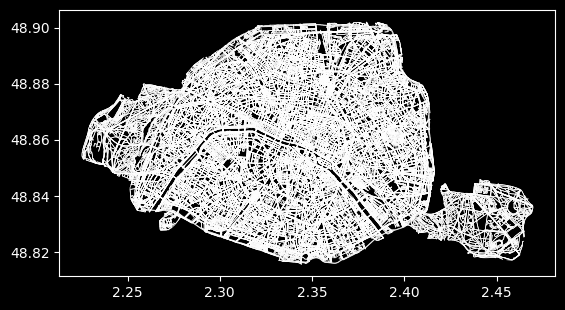

In [6]:
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
edges.plot(linewidth=0.5)
plt.show()

In [ ]:
edges = edges.to_crs(epsg=2154)

In [ ]:
import requests
from shapely.geometry import shape
from shapely.ops import unary_union

In [12]:

import requests
from shapely.geometry import shape, MultiPolygon

OVERPASS = "https://overpass-api.de/api/interpreter"


def pick_city_relation(name, admin_level="8"):
    """
    根据城市名称返回面积最大的行政区 relation（OSM）
    返回: {id, area, geometry (GeoJSON)}
    """

    q = f"""
    [out:json][timeout:180];
    relation
      ["boundary"="administrative"]
      ["admin_level"="{admin_level}"]
      ["name"="{name}"];
    out tags;
    >;
    out body geom;
    """

    r = requests.post(OVERPASS, data=q)
    r.raise_for_status()
    data = r.json()["elements"]

    # 只保留 relation
    rels = [e for e in data if e["type"] == "relation"]

    if not rels:
        raise ValueError(f"No relations found for name={name}")

    best = None

    for rel in rels:
        # Overpass 把边界分成多个 polygon members
        polygons = []
        for m in rel.get("members", []):
            if m.get("geometry"):
                coords = [(p["lon"], p["lat"]) for p in m["geometry"]]
                polygons.append(shape({"type": "Polygon", "coordinates": [coords]}))

        if not polygons:
            continue

        mp = MultiPolygon(polygons)
        area = mp.area

        if (best is None) or (area > best["area"]):
            best = {
                "id": rel["id"],
                "area": area,
                "geometry": mp.__geo_interface__,
            }

    if not best:
        raise ValueError("No usable relations with geometry")

    return best


In [13]:
city = pick_city_relation("Paris", admin_level="8")
print(city["id"], city["area"])

ValueError: No usable relations with geometry

## osmium
```osmium getid ile-de-france-251222.osm.pbf r7444 -r -t -o paris_boundary.osm```

```osmium export paris_boundary.osm -f geojson -o paris_boundary.geojson```

```osmium extract --strategy=smart -p paris_boundary.geojson ile-de-france-251222.osm.pbf -o paris_s.osm.pbf```

## osmconvert
```osmconvert paris.osm.pbf > paris.osm```

In [1]:
import psycopg2
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
import py5

In [2]:
conn = psycopg2.connect(
    dbname="Test20260413", user="postgres", password="we6666", host="localhost", port="5432"
)

sql = """
    SELECT row_number() OVER () AS rid,
           geom
    FROM paris_blocks_valid
    ORDER BY geom;
"""

In [3]:
gdf = gpd.read_postgis(sql, conn, geom_col="geom", crs="EPSG:3857")
blocks = list(gdf.geometry)

print(f"Loaded {len(blocks)} blocks")

Loaded 2758 blocks


E:\0_python_envs\urbanCode\Lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [4]:
def all_polygons(g):
    """把 MultiPolygon 统一展开成 Polygon 列表"""
    if isinstance(g, Polygon):
        return [g]
    elif isinstance(g, MultiPolygon):
        return list(g.geoms)
    return []

def draw_block(poly):
    """把 polygon 缩放并居中到屏幕绘制"""

    # 窗口大小
    W, H = py5.width, py5.height

    minx, miny, maxx, maxy = poly.bounds
    cw = maxx - minx
    ch = maxy - miny

    # 留一点边距
    margin = 0.15
    scale = min((W * (1 - margin)) / cw, (H * (1 - margin)) / ch)

    # 居中偏移量
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    py5.push_matrix()
    py5.translate(W / 2, H / 2)
    py5.scale(scale, -scale)   # y 轴反向，方便直观
    py5.translate(-cx, -cy)

    py5.fill(210)
    py5.stroke(0)

    for p in all_polygons(poly):
        coords = list(p.exterior.coords)

        py5.begin_shape()
        for x, y in coords:
            py5.vertex(x, y)
        py5.end_shape(py5.CLOSE)

    py5.pop_matrix()


In [5]:
# py5显示

current = 0

def setup():
    py5.size(900, 700)
    py5.text_size(16)
    py5.text_align(py5.CENTER, py5.CENTER)


def draw():
    py5.background(255)

    global current
    b = blocks[current]
    area = b.area   # m²（EPSG:3857）

    draw_block(b)

    py5.fill(0)
    py5.text(
        f"Block {current+1}/{len(blocks)} — Area: {area:,.0f} m²\nPress 1 = next, q = quit",
        py5.width/2,
        30
    )


def key_pressed():
    global current

    if py5.key == '1':
        current = (current + 1) % len(blocks)

    if py5.key == 'q':
        py5.exit_sketch()


py5.run_sketch()